# MSCS 634 - Lab 2
## K-Nearest Neighbors (KNN) and Radius Neighbors (RNN) Classification

**Student Name:** Sebastian Capkovic

**Course:** MSCS 634 - Data Mining

**Lab Assignment:** Lab 2 - KNN and Radius Neighbors Classification using the Wine Dataset

**Date:** September 2026

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split


In [3]:
wine = load_wine()

X = wine.data
y = wine.target

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (178, 13)
Target shape: (178,)


In [4]:
print("Feature Names:")
print(wine.feature_names)

print("\nClass Names:")
print(wine.target_names)

Feature Names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Class Names:
['class_0' 'class_1' 'class_2']


In [5]:
import pandas as pd

class_counts = pd.Series(y).value_counts().sort_index()

print("Class Distribution:")
print(class_counts)

Class Distribution:
0    59
1    71
2    48
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 142
Testing set size: 36


In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [8]:
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    knn_accuracies.append(accuracy)

    print(f"K = {k}, Accuracy = {accuracy:.4f}")

K = 1, Accuracy = 0.7778
K = 5, Accuracy = 0.7222
K = 11, Accuracy = 0.7500
K = 15, Accuracy = 0.7500
K = 21, Accuracy = 0.7778


In [9]:
import pandas as pd

knn_results = pd.DataFrame({
    'K Value': k_values,
    'Accuracy': knn_accuracies
})

knn_results

,K Value,Accuracy
0,1,0.777778
1,5,0.722222
2,11,0.750000
3,15,0.750000
4,21,0.777778


In [10]:
from sklearn.neighbors import RadiusNeighborsClassifier

In [11]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

for radius in radius_values:
    rnn = RadiusNeighborsClassifier(
        radius=radius,
        outlier_label='most_frequent'
    )

    rnn.fit(X_train, y_train)

    y_pred = rnn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    rnn_accuracies.append(accuracy)

    print(f"Radius = {radius}, Accuracy = {accuracy:.4f}")

Radius = 350, Accuracy = 0.7500
Radius = 400, Accuracy = 0.7222
Radius = 450, Accuracy = 0.7222
Radius = 500, Accuracy = 0.7222
Radius = 550, Accuracy = 0.7222
Radius = 600, Accuracy = 0.7222


In [12]:
rnn_results = pd.DataFrame({
    'Radius': radius_values,
    'Accuracy': rnn_accuracies
})

rnn_results

,Radius,Accuracy
0,350,0.750000
1,400,0.722222
2,450,0.722222
3,500,0.722222
4,550,0.722222
5,600,0.722222


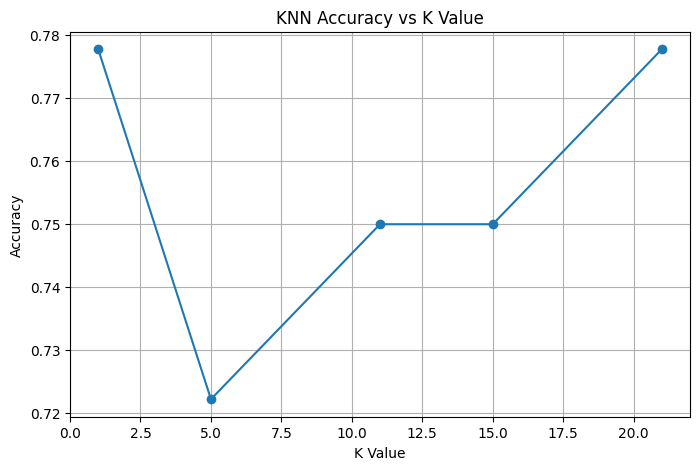

In [13]:
plt.figure(figsize=(8,5))

plt.plot(k_values, knn_accuracies, marker='o')

plt.title("KNN Accuracy vs K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

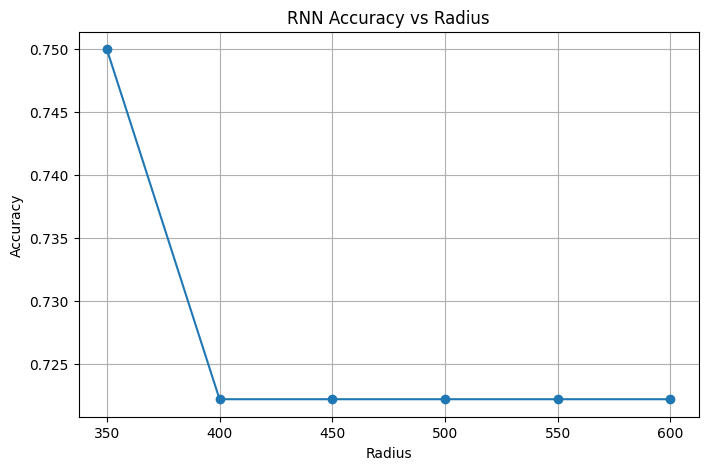

In [14]:
plt.figure(figsize=(8,5))

plt.plot(radius_values, rnn_accuracies, marker='o')

plt.title("RNN Accuracy vs Radius")
plt.xlabel("Radius")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()